Peer Groups, Service Mix, and Variance Explained



1. **Peer-group size distribution with fallback tiers**
2. **Provider HCPCS concentration + E&M mix**
3. **Variance-explained analysis for extra peer-group candidates**

The baseline peer definition from the project report is:

**Provider type × HCPCS × place of service**

This notebook stops before anomaly detection. Its purpose is to make the peer structure usable and identify which additional grouping variables are worth considering.


## 1. Setup

The notebook uses only the columns needed for these analyses.

Peer-group size is measured using **unique providers**, because each raw row is a provider + HCPCS + place-of-service record.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "Medicare_Physician_Other_Practitioners_by_Provider_and_Service_2024.csv"

USECOLS = [
    "Rndrng_NPI",
    "Rndrng_Prvdr_Type",
    "Rndrng_Prvdr_Ent_Cd",
    "Rndrng_Prvdr_RUCA",
    "Rndrng_Prvdr_State_Abrvtn",
    "Rndrng_Prvdr_Cntry",
    "HCPCS_Cd",
    "HCPCS_Drug_Ind",
    "Place_Of_Srvc",
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Bene_Day_Srvcs",
    "Avg_Mdcr_Alowd_Amt",
    "Avg_Mdcr_Stdzd_Amt",
]

# Load the CSV directly
df = pd.read_csv(DATA_PATH, usecols=USECOLS, low_memory=False)

print(f"Rows loaded: {len(df):,}")

Rows loaded: 9,781,673


In [2]:
before = len(df)

is_us = df["Rndrng_Prvdr_Cntry"] == "US"

impossible = (
    (df["Tot_Srvcs"] < df["Tot_Benes"]) |
    (df["Tot_Bene_Day_Srvcs"] > df["Tot_Srvcs"]) |
    (df["Avg_Mdcr_Alowd_Amt"] <= 0)
)

valid = (
    df["Rndrng_NPI"].notna()
    & df["Avg_Mdcr_Stdzd_Amt"].notna()
    & (df["Avg_Mdcr_Stdzd_Amt"] > 0)
    & (df["Tot_Benes"] > 0)
    & (df["Tot_Srvcs"] > 0)
    & (df["Tot_Bene_Day_Srvcs"] >= df["Tot_Benes"])
)

df = df.loc[is_us & ~impossible & valid].copy()

if df["Rndrng_Prvdr_RUCA"].dtype.name == "category":
    df["Rndrng_Prvdr_RUCA"] = df["Rndrng_Prvdr_RUCA"].cat.add_categories("unknown").fillna("unknown")
else:
    df["Rndrng_Prvdr_RUCA"] = df["Rndrng_Prvdr_RUCA"].fillna("unknown")

df = df.drop(columns=["Rndrng_Prvdr_Cntry", "Avg_Mdcr_Alowd_Amt"])

for c in [
    "Rndrng_Prvdr_Type", "Rndrng_Prvdr_Ent_Cd", "Rndrng_Prvdr_RUCA",
    "Rndrng_Prvdr_State_Abrvtn", "HCPCS_Cd", "HCPCS_Drug_Ind", "Place_Of_Srvc"
]:
    df[c] = df[c].astype("string")

print(f"Rows removed: {before - len(df):,}")
print(f"Rows retained: {len(df):,}")

Rows removed: 616
Rows retained: 9,781,057


# 2. Peer-group size distribution and fallback tiers

The intended hierarchy is:

| Tier | Peer definition |
|---|---|
| 1 | Provider type × HCPCS × place of service |
| 2 | Provider type × HCPCS |
| 3 | Provider type × place of service |
| 4 | Provider type |

A record uses the most specific tier containing at least `MIN_PEERS` unique providers.


In [3]:
peer_tiers = {
    1: ["Rndrng_Prvdr_Type", "HCPCS_Cd", "Place_Of_Srvc"],
    2: ["Rndrng_Prvdr_Type", "HCPCS_Cd"],
    3: ["Rndrng_Prvdr_Type", "Place_Of_Srvc"],
    4: ["Rndrng_Prvdr_Type"],
}

for tier, cols in peer_tiers.items():
    sizes = (
        df.groupby(cols, observed=True)["Rndrng_NPI"]
          .nunique()
          .rename(f"peer_size_tier_{tier}")
          .reset_index()
    )
    df = df.merge(sizes, on=cols, how="left")

size_cols = [f"peer_size_tier_{t}" for t in peer_tiers]
df[size_cols].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]).T


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
peer_size_tier_1,9781057.0,11660.566412,17610.813453,1.0,9.0,89.0,1153.0,5176.0,12962.0,54252.0,82322.0,91326.0
peer_size_tier_2,9781057.0,13035.033050,19163.680638,1.0,12.0,113.0,1463.0,6046.0,14779.0,60216.0,102342.0,102342.0
peer_size_tier_3,9781057.0,39213.733250,37503.354992,1.0,806.0,2432.0,11065.0,29051.0,68288.0,139510.0,139510.0,139510.0
peer_size_tier_4,9781057.0,53601.477083,54636.596117,1.0,1326.0,2690.0,12341.0,32101.0,78939.0,187671.0,187671.0,187671.0


In [4]:
MIN_PEERS = 10

baseline_sizes = (
    df.groupby(peer_tiers[1], observed=True)["Rndrng_NPI"]
      .nunique()
      .rename("unique_providers")
      .reset_index()
)

print("Exact Type × HCPCS × POS peer-group sizes:")
print(baseline_sizes["unique_providers"].describe(
    percentiles=[.01, .05, .25, .50, .75, .90, .95, .99]
))

print(f"Groups below {MIN_PEERS} providers: "
      f"{(baseline_sizes['unique_providers'] < MIN_PEERS).mean():.1%}")


Exact Type × HCPCS × POS peer-group sizes:
count    59776.000000
mean       163.628496
std       1371.589638
min          1.000000
1%           1.000000
5%           1.000000
25%          1.000000
50%          3.000000
75%         19.000000
90%        131.000000
95%        437.000000
99%       3331.250000
max      91326.000000
Name: unique_providers, dtype: float64
Groups below 10 providers: 66.5%


In [5]:
conditions = [
    df["peer_size_tier_1"] >= MIN_PEERS,
    df["peer_size_tier_2"] >= MIN_PEERS,
    df["peer_size_tier_3"] >= MIN_PEERS,
    df["peer_size_tier_4"] >= MIN_PEERS,
]

df["peer_tier"] = np.select(conditions, [1, 2, 3, 4], default=np.nan)

labels = {
    1: "Type × HCPCS × POS",
    2: "Type × HCPCS",
    3: "Type × POS",
    4: "Type",
}
df["peer_tier_label"] = df["peer_tier"].map(labels)

tier_order = list(labels.values())
tier_summary = (
    df["peer_tier_label"].value_counts()
      .reindex(tier_order)
      .fillna(0)
      .rename_axis("peer_tier")
      .reset_index(name="rows")
)
tier_summary["row_share"] = tier_summary["rows"] / len(df)

display(tier_summary)


,peer_tier,rows,row_share
0,Type × HCPCS × POS,9679315,0.989598
1,Type × HCPCS,18819,0.001924
2,Type × POS,82752,0.008460
3,Type,29,0.000003


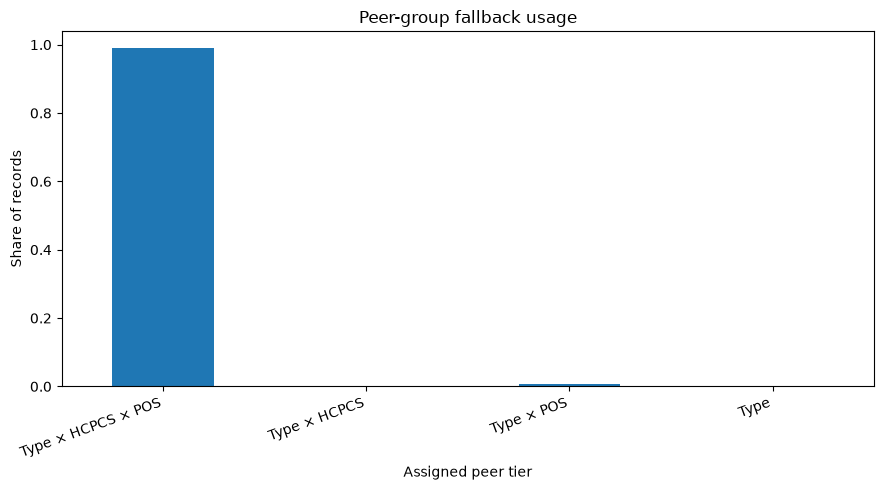

In [6]:
ax = tier_summary.plot(
    x="peer_tier", y="row_share", kind="bar",
    legend=False, figsize=(9, 5)
)
ax.set_ylabel("Share of records")
ax.set_xlabel("Assigned peer tier")
ax.set_title("Peer-group fallback usage")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### Why this matters

The fallback tier is retained as a feature so the eventual anomaly score can explain **how specific the comparison group was**.

A record in Tier 1 is compared against the most directly comparable providers. A record requiring Tier 3 or Tier 4 has less specific peer context and can be treated differently during validation.


# 3. Provider service concentration and E&M mix

Two provider-level behavioral features are added:

**HCPCS HHI:** sum of squared service shares across HCPCS codes. Higher values mean activity is concentrated in fewer services.

**E&M mix:** E&M service units divided by total service units.

For this notebook, E&M is defined as HCPCS families 992xx, 993xx, and 994xx. These are descriptive features.


In [7]:
hcpcs_num = pd.to_numeric(df["HCPCS_Cd"], errors="coerce")

df["is_em"] = (
    hcpcs_num.between(99200, 99299)
    | hcpcs_num.between(99300, 99399)
    | hcpcs_num.between(99400, 99499)
)

provider_totals = (
    df.groupby("Rndrng_NPI", observed=True)
      .agg(
          total_services=("Tot_Srvcs", "sum"),
          em_services=("Tot_Srvcs", lambda x: x[df.loc[x.index, "is_em"]].sum()),
          hcpcs_count=("HCPCS_Cd", "nunique"),
      )
)

provider_totals["em_mix"] = (
    provider_totals["em_services"] /
    provider_totals["total_services"].replace(0, np.nan)
)

provider_hcpcs = (
    df.groupby(["Rndrng_NPI", "HCPCS_Cd"], observed=True)["Tot_Srvcs"]
      .sum()
      .rename("hcpcs_services")
      .reset_index()
)

provider_hcpcs["provider_total"] = (
    provider_hcpcs.groupby("Rndrng_NPI", observed=True)["hcpcs_services"]
    .transform("sum")
)

provider_hcpcs["service_share"] = (
    provider_hcpcs["hcpcs_services"] /
    provider_hcpcs["provider_total"].replace(0, np.nan)
)

hhi = (
    provider_hcpcs.assign(share_sq=provider_hcpcs["service_share"] ** 2)
    .groupby("Rndrng_NPI", observed=True)["share_sq"]
    .sum()
    .rename("hcpcs_hhi")
)

provider_features = provider_totals.join(hhi)

df = df.merge(
    provider_features[["em_mix", "hcpcs_hhi", "hcpcs_count"]],
    left_on="Rndrng_NPI",
    right_index=True,
    how="left"
)

display(provider_features[["em_mix", "hcpcs_hhi", "hcpcs_count"]].describe(
    percentiles=[.01, .05, .25, .50, .75, .95, .99]
))


,em_mix,hcpcs_hhi,hcpcs_count
count,1.207388e+06,1.207388e+06,1.207388e+06
mean,4.618886e-01,4.155703e-01,7.800078e+00
std,4.054948e-01,2.738272e-01,9.764212e+00
min,0.000000e+00,1.332007e-02,1.000000e+00
1%,0.000000e+00,6.925877e-02,1.000000e+00
5%,0.000000e+00,1.112721e-01,1.000000e+00
25%,0.000000e+00,2.130864e-01,3.000000e+00
50%,4.528302e-01,3.331472e-01,5.000000e+00
75%,9.185792e-01,5.229592e-01,9.000000e+00
95%,1.000000e+00,1.000000e+00,2.400000e+01


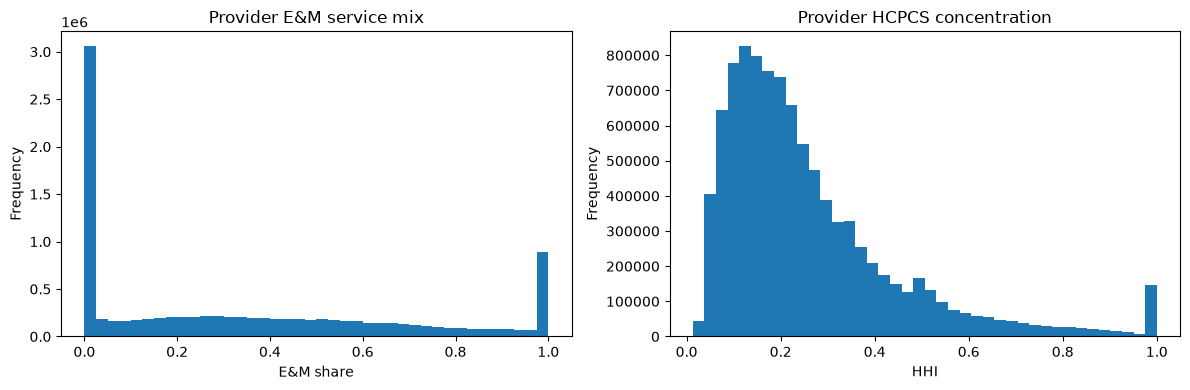

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["em_mix"].clip(0, 1).plot(
    kind="hist", bins=40, ax=axes[0], title="Provider E&M service mix"
)
axes[0].set_xlabel("E&M share")

df["hcpcs_hhi"].clip(0, 1).plot(
    kind="hist", bins=40, ax=axes[1], title="Provider HCPCS concentration"
)
axes[1].set_xlabel("HHI")

plt.tight_layout()
plt.show()


# 4. Variance explained by candidate peer-group variables

calculate **eta-squared (η²)** for log standardized Medicare payment.



> How much of the variation in standardized payment is associated with differences between groups defined by each candidate variable?

Candidate variables include the existing peer variables plus possible additions:

- provider type
- HCPCS
- place of service
- RUCA
- entity type
- state
- Part B drug indicator



In [9]:
df["log_stdzd_payment"] = np.log1p(
    df["Avg_Mdcr_Stdzd_Amt"].clip(lower=0)
)

candidate_groups = [
    "Rndrng_Prvdr_Type",
    "HCPCS_Cd",
    "Place_Of_Srvc",
    "Rndrng_Prvdr_RUCA",
    "Rndrng_Prvdr_Ent_Cd",
    "Rndrng_Prvdr_State_Abrvtn",
    "HCPCS_Drug_Ind",
]

def eta_squared(data, group_col, target_col="log_stdzd_payment"):
    x = data[[group_col, target_col]].dropna()
    grand_mean = x[target_col].mean()

    grouped = x.groupby(group_col, observed=True)[target_col].agg(["mean", "count"])
    between_ss = ((grouped["mean"] - grand_mean) ** 2 * grouped["count"]).sum()
    total_ss = ((x[target_col] - grand_mean) ** 2).sum()

    return {
        "candidate": group_col,
        "groups": len(grouped),
        "eta_squared": between_ss / total_ss if total_ss else np.nan
    }

variance_results = pd.DataFrame(
    [eta_squared(df, c) for c in candidate_groups]
).sort_values("eta_squared", ascending=False)

display(variance_results)


,candidate,groups,eta_squared
1,HCPCS_Cd,6471,0.920633
0,Rndrng_Prvdr_Type,113,0.151156
6,HCPCS_Drug_Ind,2,0.024512
2,Place_Of_Srvc,2,0.022096
4,Rndrng_Prvdr_Ent_Cd,2,0.008265
5,Rndrng_Prvdr_State_Abrvtn,61,0.004356
3,Rndrng_Prvdr_RUCA,23,0.001947


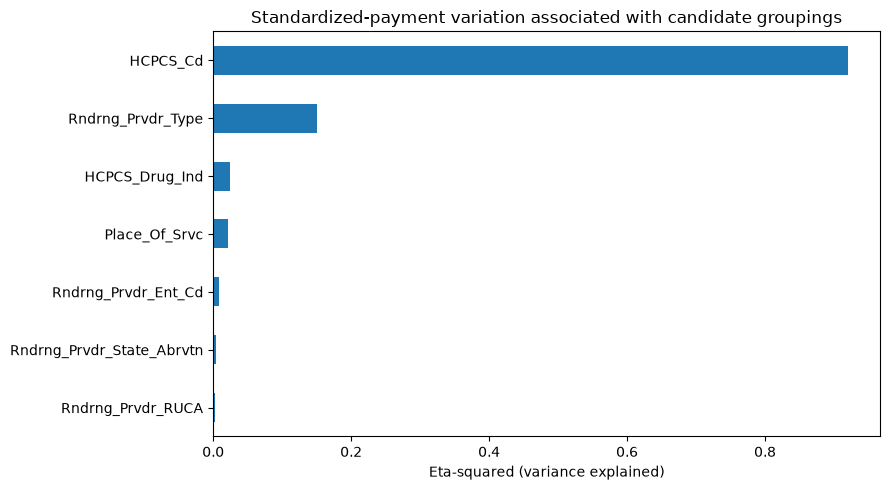

In [10]:
ax = variance_results.sort_values("eta_squared").plot(
    x="candidate", y="eta_squared", kind="barh",
    legend=False, figsize=(9, 5)
)
ax.set_xlabel("Eta-squared (variance explained)")
ax.set_ylabel("")
ax.set_title("Standardized-payment variation associated with candidate groupings")
plt.tight_layout()
plt.show()


## Extra peer-group candidates only

The baseline already contains provider type, HCPCS, and place of service. The next table isolates the variables that could be added to that baseline.



In [11]:
baseline_vars = {
    "Rndrng_Prvdr_Type",
    "HCPCS_Cd",
    "Place_Of_Srvc",
}

extra_candidates = variance_results[
    ~variance_results["candidate"].isin(baseline_vars)
].copy()

display(extra_candidates)


,candidate,groups,eta_squared
6,HCPCS_Drug_Ind,2,0.024512
4,Rndrng_Prvdr_Ent_Cd,2,0.008265
5,Rndrng_Prvdr_State_Abrvtn,61,0.004356
3,Rndrng_Prvdr_RUCA,23,0.001947


# 5. Part B output summary

These are the three outputs to carry into the report:

- **Peer fallback usage:** how often the intended peer group is large enough.
- **Provider mix features:** E&M mix and HCPCS concentration are ready for later anomaly scoring/explanation.
- **Variance explained:** shows whether RUCA, state, entity type, or drug status adds enough separation in payment to justify further peer-group testing.



In [12]:
print("=== PEER FALLBACK USAGE ===")
display(tier_summary)

print("=== PROVIDER BEHAVIOR FEATURES ===")
display(pd.DataFrame({
    "feature": ["em_mix", "hcpcs_hhi", "hcpcs_count"],
    "median": [
        df["em_mix"].median(),
        df["hcpcs_hhi"].median(),
        df["hcpcs_count"].median()
    ],
    "p95": [
        df["em_mix"].quantile(.95),
        df["hcpcs_hhi"].quantile(.95),
        df["hcpcs_count"].quantile(.95)
    ]
}))

print("=== EXTRA PEER-GROUP CANDIDATES ===")
display(extra_candidates)


=== PEER FALLBACK USAGE ===


,peer_tier,rows,row_share
0,Type × HCPCS × POS,9679315,0.989598
1,Type × HCPCS,18819,0.001924
2,Type × POS,82752,0.008460
3,Type,29,0.000003


=== PROVIDER BEHAVIOR FEATURES ===


,feature,median,p95
0,em_mix,0.268072,1.000000
1,hcpcs_hhi,0.207258,0.657509
2,hcpcs_count,13.000000,58.000000


=== EXTRA PEER-GROUP CANDIDATES ===


,candidate,groups,eta_squared
6,HCPCS_Drug_Ind,2,0.024512
4,Rndrng_Prvdr_Ent_Cd,2,0.008265
5,Rndrng_Prvdr_State_Abrvtn,61,0.004356
3,Rndrng_Prvdr_RUCA,23,0.001947
